In [ ]:
import requests
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform
import xgboost as xgb
import argparse
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
!pip install pmdarima
import pmdarima as pm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.4 MB/s eta 0:00:00


**Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Tugas Akhir Zia/ml_ready_with_hypothetical_po_beta.csv")
usdidrdf = pd.read_csv("/content/drive/MyDrive/Tugas Akhir Zia/USD_IDR_Monthly.csv")

In [ ]:
import pandas as pd

# Convert Date in usdidrdf to datetime and normalize to start of month
usdidrdf['date_dt'] = pd.to_datetime(usdidrdf['Date'], format='%m/%d/%Y')
usdidrdf['merge_date'] = usdidrdf['date_dt'].dt.to_period('M').dt.to_timestamp()

# Ensure the main df date is also datetime and normalized
df['date'] = pd.to_datetime(df['date'])
df['merge_date'] = df['date'].dt.to_period('M').dt.to_timestamp()

# Keep only necessary columns from usdidrdf for the merge
usd_subset = usdidrdf[['merge_date', 'Change %']].rename(columns={'Change %': 'usd_change_rate'})

# Remove duplicate months if any in the exchange rate data
usd_subset = usd_subset.drop_duplicates(subset=['merge_date'])

# Merge onto df
df = df.merge(usd_subset, on='merge_date', how='left')

# Clean up temporary merge column
df = df.drop(columns=['merge_date'])

print("USD/IDR exchange rates attached to the main dataframe.")
display(df.head())

USD/IDR exchange rates attached to the main dataframe.


,date,product,forecast,split,actual,lag_1,lag_2,lag_3,lag_6,lag_12,...,month_sin,month_cos,quarter,is_lebaran_window,is_year_end,year_index,fc_error_1,fc_acc_1,hypothetical_po_on_thismonth,usd_change_rate
0,2021-01-01,MU-250-40Kg,1700000.0,train,1104730.0,NaN,NaN,NaN,NaN,NaN,...,0.500000,8.660254e-01,1,0,0,0,NaN,NaN,853918.0,NaN
1,2021-02-01,MU-250-40Kg,1050000.0,train,1203670.0,1104730.0,NaN,NaN,NaN,NaN,...,0.866025,5.000000e-01,1,0,0,0,-0.538838,1.538838,931730.0,1.57%
2,2021-03-01,MU-250-40Kg,800000.0,train,1523530.0,1203670.0,1104730.0,NaN,NaN,NaN,...,1.000000,6.123234e-17,1,1,0,0,0.127668,0.872332,878794.0,1.97%
3,2021-04-01,MU-250-40Kg,1000000.0,train,1031970.0,1523530.0,1203670.0,1104730.0,NaN,NaN,...,0.866025,-5.000000e-01,2,1,0,0,0.474904,0.525096,686983.0,-0.55%
4,2021-05-01,MU-250-40Kg,400000.0,train,319490.0,1031970.0,1523530.0,1203670.0,NaN,NaN,...,0.500000,-8.660254e-01,2,0,0,0,0.030980,0.969020,242509.0,-1.14%


In [ ]:
import pandas as pd

# Fill NaN values with '0%'
df['usd_change_rate'] = df['usd_change_rate'].fillna('0%')

# Convert string percentages to floats, correctly handling negative signs
def convert_percent_to_float(x):
    if isinstance(x, str):
        # .strip('%') keeps the '-' sign, so float() converts it to a negative number
        return float(x.strip('%')) / 100
    return x

df['usd_change_rate'] = df['usd_change_rate'].apply(convert_percent_to_float)

# Verification
print(f"Column data type: {df['usd_change_rate'].dtype}")
print(f"Minimum value: {df['usd_change_rate'].min()} (Decrease)")
print(f"Maximum value: {df['usd_change_rate'].max()} (Increase)")

# Display a mix of positive and negative examples
display(df[['date', 'usd_change_rate']].drop_duplicates().sort_values('usd_change_rate').head(10))

Column data type: float64
Minimum value: -0.0495 (Decrease)
Maximum value: 0.036699999999999997 (Increase)


,date,usd_change_rate
43,2024-08-01,-0.0495
24,2023-01-01,-0.0373
34,2023-11-01,-0.0236
27,2023-04-01,-0.0217
44,2024-09-01,-0.0204
52,2025-05-01,-0.0187
26,2023-03-01,-0.0167
7,2021-08-01,-0.0135
4,2021-05-01,-0.0114
23,2022-12-01,-0.0105


In [ ]:
unique_products = df['product'].unique()
print(f"Unique products found: {unique_products}")

Unique products found: ['MU-250-40Kg' 'MU-302-50Kg' 'MU-380-40KG' 'MU-480-Combined']


In [ ]:
def mape(y_true, y_pred):
    """
    Calculate Mean Absolute Percentage Error.
    Handles zero values in y_true by masking them.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = (y_true != 0) & ~np.isnan(y_true)
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


--- Processing SKU: MU-250-40Kg ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_9829/704642303.py:68: FutureWarning: Series.__getitem__ treat

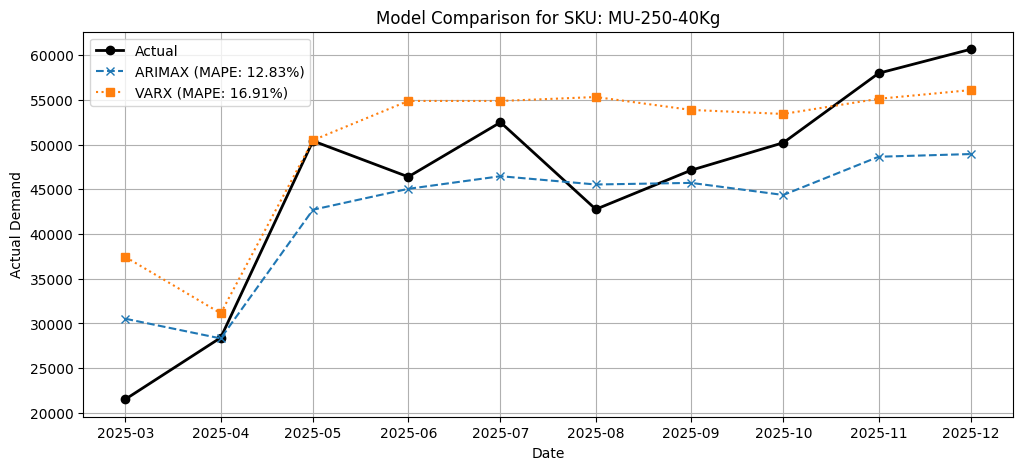


--- Processing SKU: MU-302-50Kg ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_9829/704642303.py:68: FutureWarning: Series.__getitem__ treat

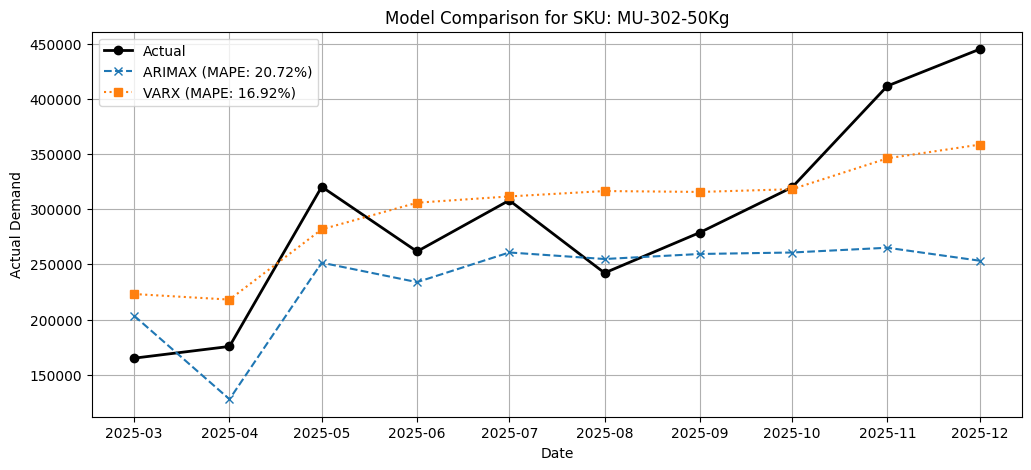


--- Processing SKU: MU-380-40KG ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_9829/704642303.py:68: FutureWarning: Series.__getitem__ treat

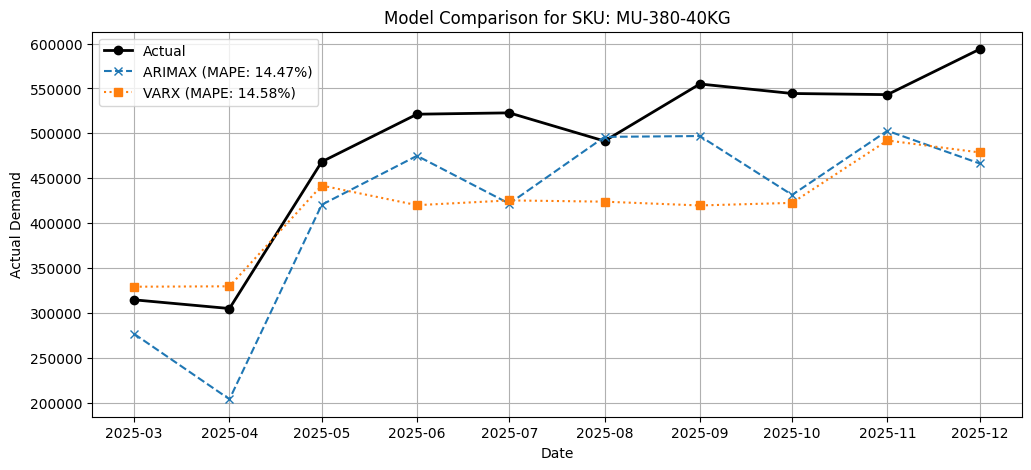


--- Processing SKU: MU-480-Combined ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_9829/704642303.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if preds_varx[0] is not Non

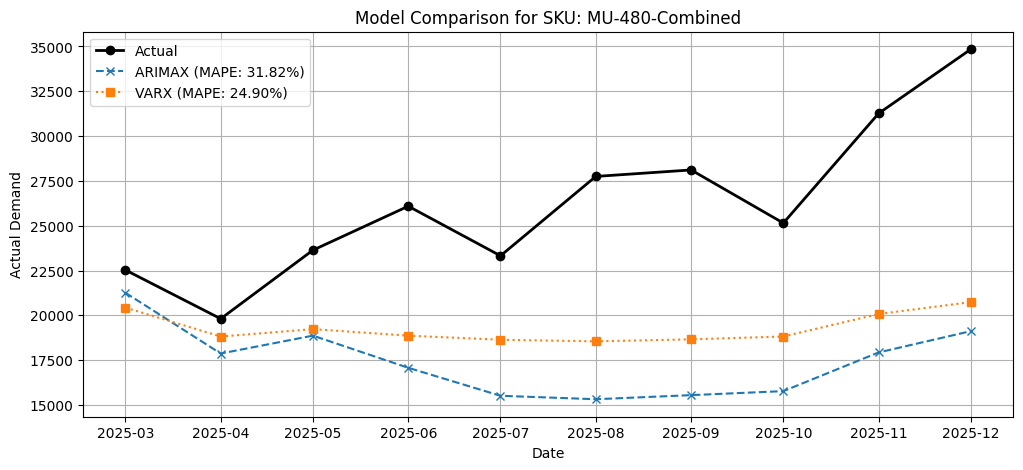

In [ ]:
from statsmodels.tsa.api import VARMAX
import matplotlib.pyplot as plt

# Create dataframes for each SKU
sku_dataframes = {sku: df[df['product'] == sku].copy() for sku in unique_products}

results_arimax = {}
results_varx = {}

for sku, sku_df in sku_dataframes.items():
    print(f"\n--- Processing SKU: {sku} ---")

    # Preprocessing
    sku_df['date'] = pd.to_datetime(sku_df['date'])
    sku_df = sku_df.sort_values('date')

    # Split
    train_sku = sku_df[(sku_df['date'] > '2021-12-01') & (sku_df['date'] < '2025-03-01')]
    test_sku = sku_df[sku_df['date'] >= '2025-03-01']

    if len(train_sku) < 5 or len(test_sku) == 0:
        print(f"Skipping {sku} due to insufficient data.")
        continue

    # 1. ARIMAX Fitting & Forecasting
    FEATURE_EXOG = ['is_lebaran_window', 'is_year_end', 'fc_error_1', 'fc_acc_1', 'usd_change_rate']
    X_train_exog = train_sku[FEATURE_EXOG]
    X_test_exog = test_sku[FEATURE_EXOG]
    y_train_sku = train_sku['actual']
    y_test_sku = test_sku['actual']

    model_arimax = pm.auto_arima(
        y_train_sku, X=X_train_exog, seasonal=True, m=12,
        suppress_warnings=True, stepwise=True
    )
    preds_arimax = model_arimax.predict(n_periods=len(y_test_sku), X=X_test_exog)
    results_arimax[sku] = mape(y_test_sku, preds_arimax)

    # 2. VARX Fitting & Forecasting
    # Using actual and fc_error_1 as endogenous, others as exogenous
    var_endog = ['actual', 'fc_error_1']
    var_exog = ['is_lebaran_window', 'is_year_end', 'fc_acc_1', 'usd_change_rate']

    train_var = train_sku[var_endog].copy()
    train_var.index = train_sku['date']
    exog_train_var = train_sku[var_exog].copy()
    exog_train_var.index = train_sku['date']

    exog_test_var = test_sku[var_exog].copy()
    exog_test_var.index = test_sku['date']

    try:
        model_varx = VARMAX(train_var, exog=exog_train_var, order=(1, 0), enforce_stationarity=False)
        varx_res = model_varx.fit(disp=False)
        # Forecast
        forecast_varx = varx_res.predict(start=len(train_sku), end=len(train_sku)+len(test_sku)-1, exog=exog_test_var)
        preds_varx = forecast_varx['actual']
        results_varx[sku] = mape(y_test_sku, preds_varx)
    except:
        print(f"VARX failed for {sku}")
        preds_varx = [None] * len(y_test_sku)
        results_varx[sku] = float('nan')

    # 3. Plotting comparison for the SKU
    plt.figure(figsize=(12, 5))
    plt.plot(test_sku['date'], y_test_sku, label='Actual', marker='o', color='black', linewidth=2)
    plt.plot(test_sku['date'], preds_arimax, label=f'ARIMAX (MAPE: {results_arimax[sku]:.2f}%)', linestyle='--', marker='x')
    if preds_varx[0] is not None:
        plt.plot(test_sku['date'], preds_varx, label=f'VARX (MAPE: {results_varx[sku]:.2f}%)', linestyle=':', marker='s')

    plt.title(f'Model Comparison for SKU: {sku}')
    plt.xlabel('Date')
    plt.ylabel('Actual Demand')
    plt.legend()
    plt.grid(True)
    plt.show()

### Recursive 3-Month Forecast (Jan-Mar 2026)
We will select the model with the lowest MAPE for each SKU and project demand for the first three months of the next period.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


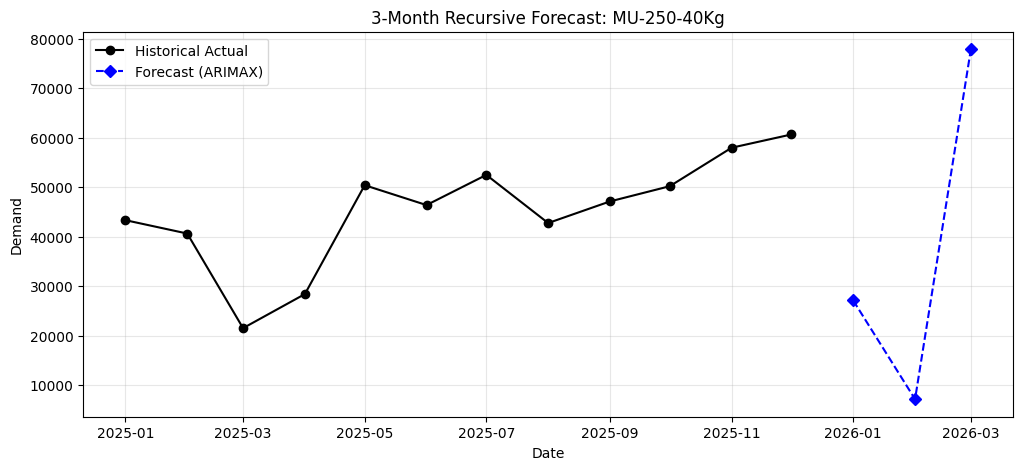

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index

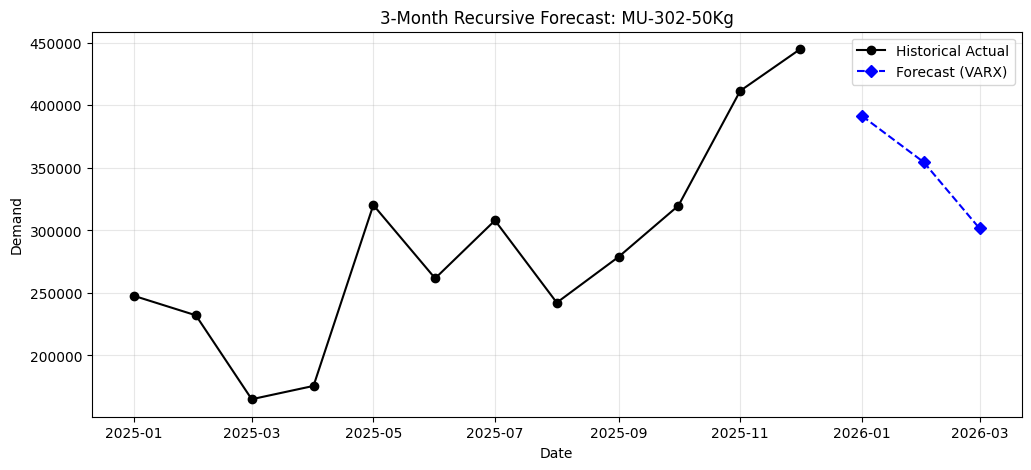

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


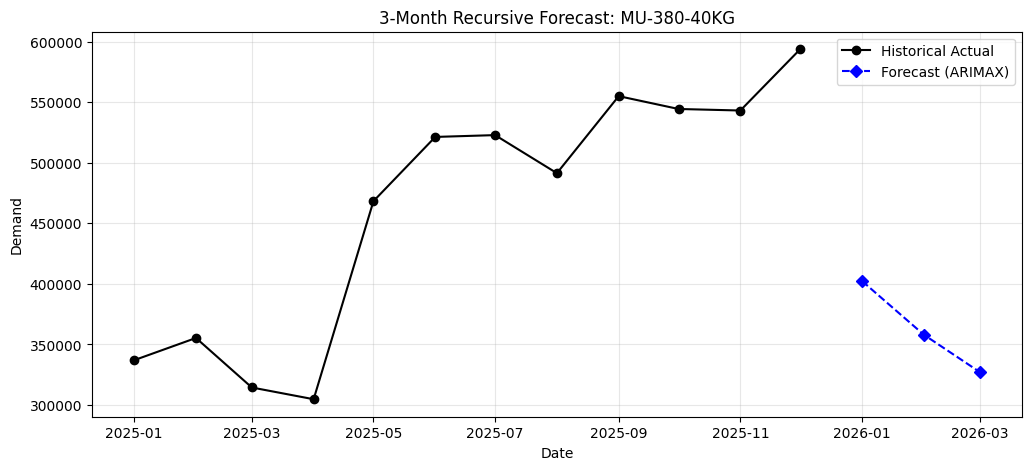

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index

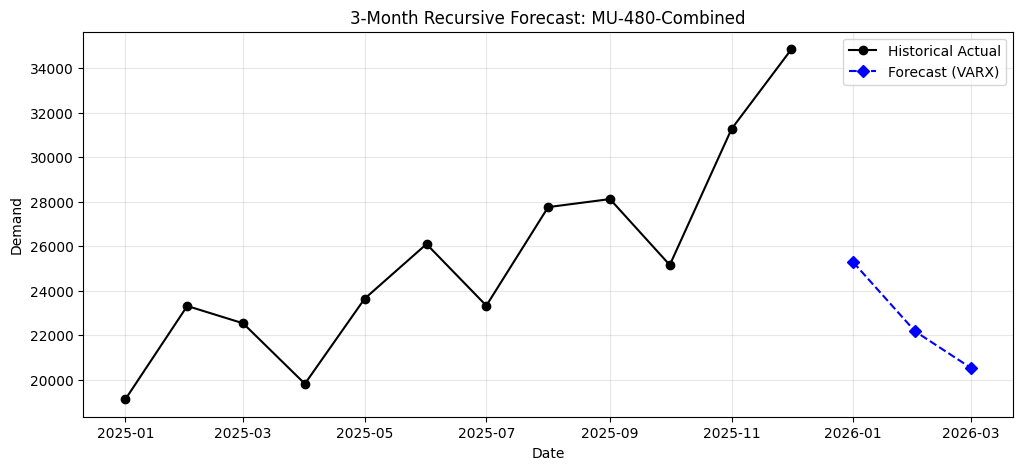

,MU-250-40Kg,MU-302-50Kg,MU-380-40KG,MU-480-Combined
Jan 2026,27107.993338,391641.073059,402380.307705,25268.790647
Feb 2026,7155.372229,354604.078981,358047.631161,22166.407941
Mar 2026,77893.259777,301633.892280,327285.194345,20521.753915


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the forecast horizon
forecast_months = pd.to_datetime(['2026-01-01', '2026-02-01', '2026-03-01'])
final_forecasts = {}

for sku in unique_products:
    # 1. Determine best model based on previous test MAPE
    m_arimax = results_arimax.get(sku, float('inf'))
    m_varx = results_varx.get(sku, float('inf'))
    best_model_type = 'ARIMAX' if m_arimax <= m_varx else 'VARX'

    sku_df = sku_dataframes[sku].copy()
    sku_df['date'] = pd.to_datetime(sku_df['date'])
    sku_df = sku_df.sort_values('date')
    sku_df = sku_df.dropna(subset=['actual', 'is_lebaran_window', 'is_year_end', 'fc_error_1', 'fc_acc_1'])

    # Future exogenous variables for recursion
    future_exog_data = []
    for dt in forecast_months:
        future_exog_data.append({
            'date': dt,
            'is_lebaran_window': 1 if dt.month in [3, 4] else 0,
            'is_year_end': 1 if dt.month == 12 else 0,
            'fc_acc_1': 0.8,
            'fc_error_1': 0.2
        })
    future_exog_df = pd.DataFrame(future_exog_data).set_index('date')

    # 2. Refit and Forecast
    full_y = sku_df['actual']
    full_X_exog = sku_df[['is_lebaran_window', 'is_year_end', 'fc_error_1', 'fc_acc_1']]

    if best_model_type == 'ARIMAX':
        model = pm.auto_arima(full_y, X=full_X_exog, seasonal=True, m=12, suppress_warnings=True)
        forecast_values = model.predict(n_periods=3, X=future_exog_df[['is_lebaran_window', 'is_year_end', 'fc_error_1', 'fc_acc_1']])
    else:
        endog = sku_df[['actual', 'fc_error_1']]
        exog = sku_df[['is_lebaran_window', 'is_year_end', 'fc_acc_1']]
        model_var = VARMAX(endog, exog=exog, order=(1, 0), enforce_stationarity=False)
        res_var = model_var.fit(disp=False)
        forecast_res = res_var.predict(start=len(sku_df), end=len(sku_df)+2, exog=future_exog_df[['is_lebaran_window', 'is_year_end', 'fc_acc_1']])
        forecast_values = forecast_res['actual']

    final_forecasts[sku] = list(forecast_values)

    # 3. Plotting for each SKU
    plt.figure(figsize=(12, 5))
    # Plot historical (last 12 months for clarity)
    hist_plot = sku_df.tail(12)
    plt.plot(hist_plot['date'], hist_plot['actual'], label='Historical Actual', marker='o', color='black')
    # Plot forecast
    plt.plot(forecast_months, forecast_values, label=f'Forecast ({best_model_type})', marker='D', linestyle='--', color='blue')

    plt.title(f'3-Month Recursive Forecast: {sku}')
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Summary table
forecast_summary = pd.DataFrame(final_forecasts, index=['Jan 2026', 'Feb 2026', 'Mar 2026'])
display(forecast_summary)